---
tags: [algorithm, optimization, variational]
---

# フィードバックベースの量子最適化手法

量子コンピュータは、組合せ最適化分野において古典コンピュータに対する優位性をもたらすと期待されています。
組合せ最適化問題を解くための手法として、量子近似最適化アルゴリズム (QAOA) が考えられましたが、これは古典最適化を必要とします。
ここでは、古典的な変分パラメータ最適化を用いず、測定に基づくフィードバックを利用した量子最適化手法 Feedback-based ALgorithm for Quantum OptimizatioN (FALQON) を提案した [Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) について解説します。
また FALQON の Qamomile による実装を示し、MaxCut 問題を通してその実装の確認を行います。

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit]"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from qiskit_aer import AerSimulator
import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.qiskit import QiskitTranspiler

## 背景

### 組合せ最適化と量子最適化手法

組合せ最適化は、物流やサプライチェーン・創薬など、広範かつ価値のある応用を持ちます。
一般的な組合せ最適化問題は NP 困難であり、その最適解を厳密に求めることは容易ではありません。
そこで、実用的な手法として、質の高い近似解を求めることを目指す方法が注目を集めています。
量子を活用した方法として、量子アニーリングや量子近似最適化アルゴリズム (QAOA) が考えられてきました。
これらの量子技術を用いることの優位性に関する厳密な証明はまだ存在しませんが、ある程度の問題規模においては、量子優位性が存在するはずであると信じされています。

### 先行研究: 量子リアプノフ制御 (QLC)

量子最適化手法として有名な QAOA ですが、これは多数の変分パラメータを古典的に最適化する必要があり、それがスケーリングの課題となっていました。
そこで、[Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) では、量子系を望ましい方向へ制御するためにフィードバックを利用する、量子リアプノフ制御 (QLC) を応用することを提案しました。
リアプノフ関数を明示的に用いて量子系を制御する研究をした代表的なものに、[Grivopoulos & Bamieh (2003)](https://ieeexplore.ieee.org/document/1272601) があります。
この論文では、シュレディンガー方程式

$$
i \frac{d}{dt} \vert \psi \rangle 
= \left( H_0 + H_1 u_1 (t) \right) \vert \psi \rangle 
\equiv H \vert \psi \rangle \tag{1}
$$

に対し、リアプノフ関数 $V(\psi)$ が減少するようなフィードバック則 $u(t)$ を設計し、目的とする固有状態を安定化する方法を議論しました。
ここで、$H_0$ は系のハミルトニアンであり、外部から制御をしなかった場合の量子系の時間発展を表します。
そして、$H_1$ は制御ハミルトニアンで、外部の古典的な制御 $u(t)$ が量子系にどのように作用するかを表す演算子です。
[Grivopoulos & Bamieh (2003)](https://ieeexplore.ieee.org/document/1272601) では、リアプノフ関数として

$$
V(\psi) 
= \langle \psi \vert P \vert \psi \rangle \tag{2}
$$

を用いることを提案しています。
ここで $P$ はエルミート演算子で、リアプノフ関数はその期待値としています。
そして $[H_0, P] = 0$ となるように演算子 $P$ を設計します。
すると

$$
\frac{dV}{dt} 
= \left( \frac{d}{dt} \langle \psi \vert \right) P \vert \psi \rangle + \langle \psi \vert P \left( \frac{d}{dt} \vert \psi \rangle \right) 
= i \langle \psi \vert H P \vert \psi \rangle + \langle \psi \vert P (-iH) \vert \psi \rangle 
= i \langle \psi \vert [H, P] \vert \psi \rangle 
= i \langle \psi \vert [H_0 + H_1 u, P] \vert \psi \rangle 
= i u \langle \psi \vert [H_1, P] \vert \psi \rangle \tag{3}
$$

のように変形できます。
ここで $A(t) \equiv i \langle \psi \vert [H_1, P] \vert \psi \rangle$ のようにおくと

$$
\frac{dV}{dt} 
= A(t) u(t) \tag{4}
$$

のようになります。
さらに $u(t) = -A(t)$ のように選べば

$$
\frac{dV}{dt} 
= - A^2 \leq 0 \tag{5}
$$

のようになり、$V$ が時間とともに減少するように制御することができます。

## 提案手法

### QLC の応用

[Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) では、次のような量子系を考えました。

$$
i \frac{d}{dt} \vert \psi \rangle 
= \{H_p + \beta (t) H_d \} \vert \psi \rangle \tag{6}
$$

ここで $H_p$ は最小化したい問題のハミルトニアン、$H_d$ はドライバーハミルトニアン、$\beta (t)$ は制御パラメータです。
$E(t) = \langle \psi \vert H_p \vert \psi \rangle$ を最小化するために、$\frac{dE}{dt} \leq 0$ となるような制御パラメータ $\beta(t)$ を設計しましょう。
先ほどの QLC での議論から、式 (3) において $P \rightarrow H_p, H_1 \rightarrow H_d$ のようにすることで

$$
\frac{dE}{dt} 
= i \beta(t) \langle \psi \vert [H_d, H_p] \vert \psi \rangle \tag{7}
$$

を得ます。
ここで $A(t) \equiv i \langle \psi \vert [H_d, H_p] \vert \psi \rangle$ と定義すると

$$
\frac{dE}{dt} 
= A(t) \beta(t) \tag{8}
$$

が得られるため、単純に

$$
\beta(t) 
= - A(t) \tag{9}
$$

のように選ぶことで $\frac{dE}{dt} = - A(t)^2 \leq 0$ のように、減少する $E(t)$ を再現することができます。

### 量子回路の構築

先ほどの手法を量子回路にするために、$\Delta t$ の幅で時間を離散化しましょう。
そして問題ハミルトニアンとドライバーハミルトニアンによる時間発展演算子をそれぞれ

$$
U_p = e^{-i H_p \Delta t}, \quad U_d(\beta_k) 
= e^{-i\beta_k H_d \Delta t} \tag{10}
$$

のようにします。
ここで $\beta_k$ は $k$ ステップ目での $\beta(t)$ の値です。
これらを用いることで、$k$ ステップ後の状態が

$$
\vert \psi_k \rangle 
= U_d(\beta_k) U_p U_d(\beta_{k-1}) U_p \cdots U_d(\beta_1) U_p \vert \psi_0 \rangle \tag{11}
$$

のように求まります。
$k$ ステップ後の状態について、$A_k = i \langle \psi_k \vert [H_d, H_p] \vert \psi_k \rangle$ を測定から求め、$\beta_{k+1} = - A_k$ とすることで、$k+1$ ステップ目の制御パラメータにします。
先ほどの FALQON の単調減少の特徴は、連続時間で保証されたものです。
しかし、量子回路実装では時間を離散化します。
$\Delta t$ が大きいと単調減少性が破れることが [Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) で指摘されています。
$\Delta t$ を十分小さくとることで、連続時間に近い単調減少性を得ることができます。

### $A_k$ の測定

そのままでは $i[H_d, H_p]$ を測定できないため、これをパウリストリング $P_j \in \{X, Y, Z, I\}^{\otimes n}$ で展開します。
すなわち $i [H_d, H_p] = \sum_j \alpha_j P_j$ のようにすると

$$
A_k 
= \sum_j \alpha_j \langle \psi_k \vert P_j \vert \psi_k \rangle \tag{12}
$$

のようにして求めることができます。  
MaxCut を例に、この測定手法を見てみましょう。
MaxCut では、問題ハミルトニアンは

$$
H_p 
= - \sum_{(i, j) \in \mathcal{E}} \frac{1}{2} (1 - Z_i Z_j) \tag{13}
$$

のように書かれます。
ここで $\mathcal{E}$ はグラフの辺集合です。
そしてドライバーハミルトニアンを

$$
H_d 
= \sum_{j=1}^n X_j \tag{14}
$$

とすると

$$
i [H_d, H_p] 
= \sum_{(i, j) \in \mathcal{E}} (Y_i Z_j + Z_i Y_j) \tag{15}
$$

となります。
したがって、MaxCut では

$$
A_k 
= \sum_{(i, j) \in \mathcal{E}} ( \langle \psi_k \vert Y_i Z_j \vert \psi_k \rangle + \langle \psi_k \vert Z_i Y_j \vert \psi_k \rangle ) \tag{16}
$$

のように、$YZ, ZY$ のような 2 量子ビットパウリストリングの期待値を測定すれば良いとわかります。
ある量子状態を用いて $Y_i Z_j$ を測定した後では、測定により状態が壊れるため、同じ状態を用いて $Z_i Y_j$ を測定することはできません。
そこで例えば複数回の測定から $\langle \psi_k \vert Y_i Z_j \vert \psi_k \rangle$ を推定したのち、再び $\langle \psi_k \vert Z_i Y_j \vert \psi_k \rangle$ を推定するための測定を複数回行います。
非可換な項や異なる測定基底を必要とする項については、量子状態を再準備し、別々に測定する必要があります。
そのため、FALQON は測定コストが大きくなる傾向にあります。
ただし、同一の測定基底で評価可能なパウリストリングをグループ化することで、必要な測定回数を削減することができます。


## Qamomile による実装

[Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) で提案された FALQON を、Qamomile で実装しましょう。

### インスタンスの作成

今回は [Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) と同様に、MaxCut 問題を解くことにします。

Number of vertices: 5
Number of edges: 6


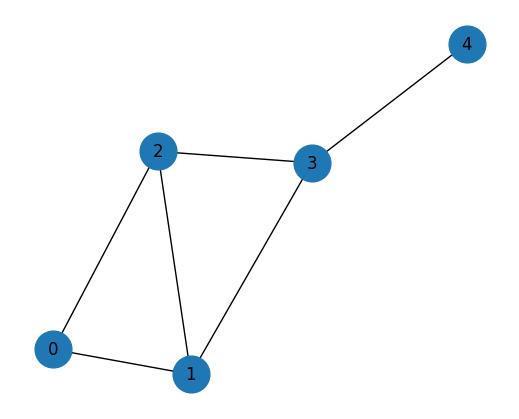

In [3]:
G = nx.Graph()

G.add_edges_from(
    [
        (0, 1),
        (0, 2),
        (1, 2),
        (1, 3),
        (2, 3),
        (3, 4),
    ]
)

n = G.number_of_nodes()
m = G.number_of_edges()

print("Number of vertices:", n)
print("Number of edges:", m)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=700,
)
plt.show()

### $H_p, H_d, [H_d, H_p]$ の作成

MaxCut のための問題ハミルトニアンは、式 (13) で与えられます。
ここでは定数項を取り除いた $H_p = \frac{1}{2} \sum_{(i, j) \in \mathcal{E}} Z_i Z_j$ を実装することにしましょう。
またドライバーハミルトニアンも、式 (14) を実装することにします。
そして交換関係 $[H_d, H_p]$ の実装には、Qamomile の `commutator` を用いるのが便利です。

In [4]:
Hp = qm_o.Hamiltonian(num_qubits=n)

for i, j in G.edges():
    Hp += 0.5 * qm_o.Z(i) * qm_o.Z(j)

Hd = qm_o.Hamiltonian(num_qubits=n)

for i in range(n):
    Hd += qm_o.X(i)

print("Hp =", Hp)
print("Hd =", Hd)

commutator_h = qm_o.commutator(Hd, Hp)

feedback_h = 1j * commutator_h

print("[Hd, Hp] =")
print(commutator_h)

print("\ni[Hd, Hp] =")
print(feedback_h)

Hp = Hamiltonian((Z0, Z1): 0.5, (Z0, Z2): 0.5, (Z1, Z2): 0.5, (Z1, Z3): 0.5, (Z2, Z3): 0.5, (Z3, Z4): 0.5)
Hd = Hamiltonian((X0,): 1.0, (X1,): 1.0, (X2,): 1.0, (X3,): 1.0, (X4,): 1.0)
[Hd, Hp] =
Hamiltonian((Y0, Z1): -1j, (Y0, Z2): -1j, (Z0, Y1): -1j, (Y1, Z2): -1j, (Y1, Z3): -1j, (Z0, Y2): -1j, (Z1, Y2): -1j, (Y2, Z3): -1j, (Z1, Y3): -1j, (Z2, Y3): -1j, (Y3, Z4): -1j, (Z3, Y4): -1j)

i[Hd, Hp] =
Hamiltonian((Y0, Z1): (1+0j), (Y0, Z2): (1+0j), (Z0, Y1): (1+0j), (Y1, Z2): (1+0j), (Y1, Z3): (1+0j), (Z0, Y2): (1+0j), (Z1, Y2): (1+0j), (Y2, Z3): (1+0j), (Z1, Y3): (1+0j), (Z2, Y3): (1+0j), (Y3, Z4): (1+0j), (Z3, Y4): (1+0j))


### FALQON のカーネルの作成

式 (11) で表される、FALQON を実装しましょう。
`falqon_state` は FALQON のレイヤー層を実装し、その量子状態を生成するカーネルです。
それを用いた `falqon_expval` は $A_k$ やエネルギーを測定するための qkernel で、`falqon_sampling` は最終サンプリングを行います。 

In [13]:
@qmc.qkernel
def falqon_state(
    n: qmc.UInt,
    depth: qmc.UInt,
    betas: qmc.Vector[qmc.Float],
    delta_t: qmc.Float,
    Hp: qmc.Observable,
    Hd: qmc.Observable,
) -> qmc.Vector[qmc.Qubit]:

    q = qmc.qubit_array(n, name="q")

    # Initial state: ground state of Hd = sum_i X_i
    q = qmc.h(q)
    q = qmc.z(q)

    # FALQON layers
    for k in qmc.range(depth):

        # Up = exp(-i Hp delta_t)
        q = qmc.pauli_evolve(
            q,
            Hp,
            delta_t,
        )

        # Ud(beta_k) = exp(-i beta_k Hd delta_t)
        q = qmc.pauli_evolve(
            q,
            Hd,
            betas[k] * delta_t,
        )

    return q

@qmc.qkernel
def falqon_expval(
    n: qmc.UInt,
    depth: qmc.UInt,
    betas: qmc.Vector[qmc.Float],
    delta_t: qmc.Float,
    Hp: qmc.Observable,
    Hd: qmc.Observable,
    obs: qmc.Observable,
) -> qmc.Float:

    q = falqon_state(
        n,
        depth,
        betas,
        delta_t,
        Hp,
        Hd,
    )

    return qmc.expval(q, obs)

@qmc.qkernel
def falqon_sampling(
    n: qmc.UInt,
    depth: qmc.UInt,
    betas: qmc.Vector[qmc.Float],
    delta_t: qmc.Float,
    Hp: qmc.Observable,
    Hd: qmc.Observable,
) -> qmc.Vector[qmc.Bit]:

    q = falqon_state(
        n,
        depth,
        betas,
        delta_t,
        Hp,
        Hd,
    )

    return qmc.measure(q)

この実装では、$A_k, \langle H_p \rangle$ を `qmc.expval` により評価しています。
これは理想的な場合であり、有限の測定回数に起因する統計誤差や測定コストは、このシミュレーションには含まれないことに注意しましょう。

### FALQON のパラメータの設定

FALQON の実行に必要な $\Delta t$ と 最大 depth、そして $\beta$ の初期値などを設定しましょう。

In [14]:
delta_t = 0.1
max_layers = 20

betas = [0.0]

A_history = []
energy_history = []
cut_history = []
beta_history = [0.0]

### Qiskit へのトランスパイル

Qamomile の機能を用い、Qiskit へトランスパイルしましょう。

In [15]:
transpiler = QiskitTranspiler()

backend = AerSimulator(
    method="statevector",
    seed_simulator=42,
)

executor = transpiler.executor(backend=backend)

### FALQON のメインループ

ここまで定義した関数を用い、FALQON のフィードバックループを構築しましょう。

In [ ]:
for depth in range(1, max_layers + 1):

    # -----------------------------------------
    # A_k = < i [Hd, Hp] >
    # -----------------------------------------

    feedback_executable = transpiler.transpile(
        falqon_expval,
        bindings={
            "n": n,
            "depth": depth,
            "delta_t": delta_t,
            "Hp": Hp,
            "Hd": Hd,
            "obs": feedback_h,
        },
        parameters=["betas"],
    )

    A_k = feedback_executable.run(
        executor,
        bindings={
            "betas": betas,
        },
    ).result()

    A_k = float(np.real(A_k))

    A_history.append(A_k)

    # -----------------------------------------
    # <Hp>
    # -----------------------------------------

    energy_executable = transpiler.transpile(
        falqon_expval,
        bindings={
            "n": n,
            "depth": depth,
            "delta_t": delta_t,
            "Hp": Hp,
            "Hd": Hd,
            "obs": Hp,
        },
        parameters=["betas"],
    )

    energy_reduced = energy_executable.run(
        executor,
        bindings={
            "betas": betas,
        },
    ).result()

    energy_reduced = float(np.real(energy_reduced))

    # Original paper:
    # Hp_full = Hp - |E|/2 I
    energy_full = energy_reduced - 0.5 * m

    energy_history.append(energy_full)

    # Since Hp_full = - MaxCut operator,
    # expected cut value = - <Hp_full>
    expected_cut = -energy_full
    cut_history.append(expected_cut)

    print(
        f"depth={depth:2d}  "
        f"beta={betas[-1]: .6f}  "
        f"A={A_k: .6f}  "
        f"<Hp>={energy_full: .6f}  "
        f"<cut>={expected_cut: .6f}"
    )

    # -----------------------------------------
    # beta_{k+1} = -A_k
    # -----------------------------------------

    if depth < max_layers:
        beta_next = -A_k
        betas.append(beta_next)
        beta_history.append(beta_next)

## 結果

エネルギー $\langle H_p \rangle$ が単調に減少していることを確認しましょう。

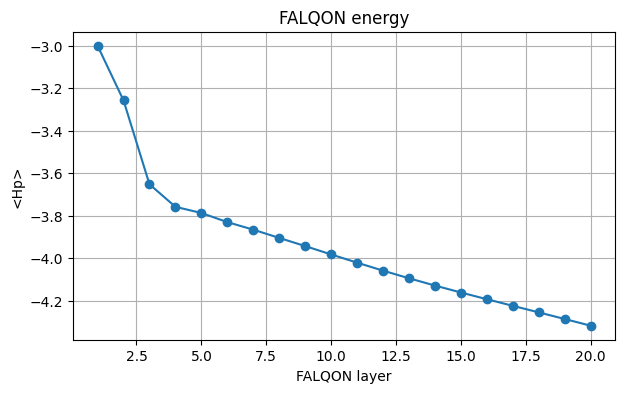

In [17]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, max_layers + 1),
    energy_history,
    marker="o",
)

plt.xlabel("FALQON layer")
plt.ylabel("<Hp>")
plt.title("FALQON energy")

plt.grid()
plt.show()

同様に、$\beta_k$ がどのように推移するかも可視化しましょう。

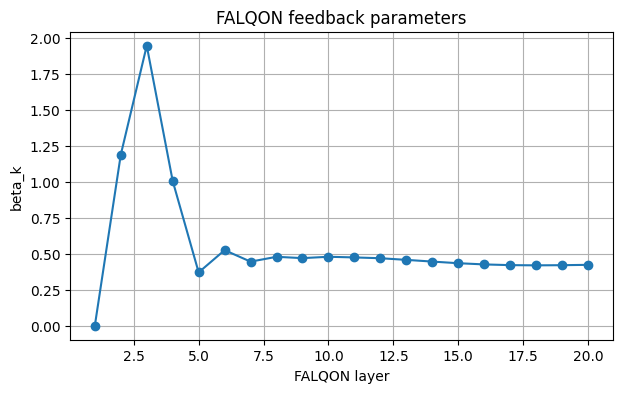

In [18]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(beta_history) + 1),
    beta_history,
    marker="o",
)

plt.xlabel("FALQON layer")
plt.ylabel("beta_k")
plt.title("FALQON feedback parameters")

plt.grid()
plt.show()

最後に、最終状態をサンプリングしましょう。

In [19]:
sampling_executable = transpiler.transpile(
    falqon_sampling,
    bindings={
        "n": n,
        "depth": max_layers,
        "delta_t": delta_t,
        "Hp": Hp,
        "Hd": Hd,
    },
    parameters=["betas"],
)

shots = 5000

sample_result = sampling_executable.sample(
    executor,
    bindings={
        "betas": betas,
    },
    shots=shots,
).result()

print(sample_result.results)

[((0, 0, 0, 1, 1), 19), ((1, 1, 1, 1, 1), 5), ((0, 1, 1, 1, 1), 39), ((0, 0, 1, 0, 0), 27), ((0, 0, 0, 0, 0), 7), ((1, 0, 1, 0, 0), 53), ((1, 0, 1, 0, 1), 118), ((1, 1, 1, 0, 0), 28), ((0, 0, 1, 0, 1), 208), ((1, 0, 0, 0, 1), 54), ((0, 0, 0, 1, 0), 95), ((0, 1, 0, 0, 0), 27), ((0, 1, 1, 0, 0), 127), ((1, 0, 1, 1, 1), 39), ((0, 0, 0, 0, 1), 21), ((1, 0, 0, 1, 1), 133), ((0, 1, 0, 1, 1), 42), ((1, 0, 0, 0, 0), 49), ((1, 1, 0, 0, 0), 48), ((0, 0, 1, 1, 1), 44), ((0, 1, 0, 1, 0), 117), ((1, 0, 1, 1, 0), 221), ((1, 1, 1, 0, 1), 79), ((0, 0, 1, 1, 0), 116), ((0, 1, 1, 0, 1), 1362), ((1, 1, 0, 1, 1), 29), ((1, 0, 0, 1, 0), 1310), ((1, 1, 0, 1, 0), 190), ((0, 1, 0, 0, 1), 212), ((0, 1, 1, 1, 0), 45), ((1, 1, 0, 0, 1), 113), ((1, 1, 1, 1, 0), 23)]


得られたビット列から MaxCut を求め、最終的な解候補を見てみましょう。

In [20]:
best_cut = -1
best_bits = None
best_count = 0

for value, count in sample_result.results:

    # value is already a tuple such as (0, 1, 0, 1, ...)
    bits = list(value)

    cut = sum(
        bits[i] != bits[j]
        for i, j in G.edges()
    )

    if cut > best_cut:
        best_cut = cut
        best_bits = bits
        best_count = count

print("Best bit string:", best_bits)
print("Best cut:", best_cut)
print("Count:", best_count)

Best bit string: [0, 1, 1, 0, 1]
Best cut: 5
Count: 1362


6 つの辺のうちの 5 つをカットする解を得ることができました。

## まとめ

ここでは、[Magann et al. (2022)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.129.250502) で提案された FALQON について解説し、それを Qamomile で実装した例を示しました。
以下に重要な情報をまとめます。

* FALQON は量子リアプノフ制御の考えに基づいたもので、量子回路の測定結果を次の回路パラメータへフィードバックする手法です。
* QAOA が複数の変分パラメータを古典最適化器によって探索するのに対し、FALQON は量子測定から得られる値を用い、次のパラメータを直接決定します。
* Qamomile を用いることで、問題ハミルトニアン $H_p$ やドライバーハミルトニアン $H_d$ 、そして交換関係 $[H_d, H_p]$ を直接記述することができます。
* また `pauli_evolve` により $e^{-i H \Delta t}$ を簡潔に記述でき、FALQON の数式と量子回路実装を対応させることができます。